# Notebook 01 — Exploratory Data Analysis: Summary of Findings

## Overview
This notebook explores the PaySim synthetic financial transaction dataset 
to understand the structure of fraud before any modelling begins. The goal 
was to answer three questions: where does fraud occur, what does it look 
like statistically, and does the network structure of transactions reveal 
patterns that raw transaction data cannot?

---

## Finding 1: Severe class imbalance
Of 6,362,620 total transactions, only 8,213 are fraudulent — a rate of 
0.1291%. This imbalance means accuracy is not a valid evaluation metric. 
A model predicting "not fraud" for every transaction would score 99.87% 
accuracy while catching zero fraudsters. We will evaluate using precision, 
recall, and F1 score instead.

## Finding 2: Fraud is exclusive to two transaction types
Fraud occurs only in TRANSFER and CASH_OUT transactions — zero fraud exists 
in PAYMENT, CASH_IN, or DEBIT. This is structurally suspicious: these are 
the only two transaction types that move funds out of the network entirely. 
The dataset was filtered to these two types only, reducing to 2,770,409 
transactions.

## Finding 3: Graph structure of the transaction network
Modelling filtered transactions as a directed weighted graph (accounts as 
nodes, transactions as directed edges weighted by amount) produced:
- 3,277,509 nodes
- 2,770,409 edges
- Average degree: 1.69
- Maximum degree: 75
- 2,894,347 nodes (88%) with degree 1 — appearing in exactly one transaction

The most connected account had in-degree 75 and out-degree 0 — receiving 
funds from 75 different sources while never sending. A strong collector 
pattern.

## Finding 4: Fraud accounts play two structurally distinct roles
Of 8,213 fraudulent transactions:
- 8,213 unique sending accounts — every fraud originator sent exactly once
- 8,169 unique receiving accounts — 44 received fraud from multiple sources
- Zero overlap between senders and receivers

The fraud network is bipartite-like: dedicated throwaway originators and 
dedicated collector accounts, never swapping roles.

## Finding 5: In-degree and out-degree separate fraud from normal accounts

| Account type      | Avg in-degree | Avg out-degree |
|-------------------|---------------|----------------|
| Fraud originators | 0.0000        | 1.0019         |
| Fraud receivers   | 5.6563        | 0.0007         |
| Normal accounts   | 0.8354        | 0.8470         |

Fraud receivers receive money from nearly 7 times as many sources as normal 
accounts. Fraud originators have zero incoming connections. These structural 
signatures are invisible to tabular models and only detectable through the 
graph — the core empirical justification for this project's approach.

## Finding 6: Fraud transactions are significantly larger
Fraud transactions have a mean of $1,467,967 versus $314,115 for normal 
transactions — 4.7 times larger. However amount alone is insufficient: 
normal transactions reach $92 million, far above the fraud ceiling of 
$10 million. Amount gains predictive power when combined with graph features.

## Finding 7: Fraud amount distributions suggest two fraud behaviours
The fraud amount distribution shows a possible bimodal shape — smaller 
frauds between $100–$100,000 and larger ones between $500,000–$2,000,000. 
Normal amounts are tightly concentrated in one range. High variability in 
fraud amounts versus the predictability of normal amounts is itself a 
detectable signal.

---

## Decisions carried forward into notebook 02

1. Filter to TRANSFER and CASH_OUT transactions only
2. Remove zero-amount transactions (data quality artefact)
3. Build a directed weighted graph — direction encodes the sender/receiver 
   distinction which carries fraud signal
4. Use in-degree and out-degree as separate features, not combined degree
5. Evaluate all models using precision, recall, and F1 — not accuracy


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('../data/raw/PS_20174392719_1491204439457_log.csv')

print(df.shape)
print(df.head())
print(df.dtypes)


(6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
step                int64
type                  str
amount            float64
nameOrig     

In [3]:
print(df['isFraud'].value_counts())

print(f"\nFraud percentage: {df['isFraud'].mean() * 100:.4f}%")
print(f"\nTransaction types:\n{df['type'].value_counts()}")


isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage: 0.1291%

Transaction types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [4]:
print(df.groupby('type')['isFraud'].sum())
print(f"\nMissing values: \n{df.isnull().sum()}")
df_filtered = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]
print(f"\nFiltered dataset shape: {df_filtered.shape}")

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

Missing values: 
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Filtered dataset shape: (2770409, 11)


In [5]:
import networkx as nx

#Build directed graph

G = nx.DiGraph()
for _, row in df_filtered.iterrows():
    G.add_edge(row['nameOrig'], row['nameDest'], weighted=row['amount'], isFraud=row['isFraud'])
    
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")


Nodes: 3277509
Edges: 2770409


In [6]:
#Basic graph facts 
print(f"Is directed: {G.is_directed()}")
print(f"Average degree: {sum(dict(G.degree()).values())/G.number_of_nodes():.4f}")

#Degree = number of connections a node has 
degrees = dict(G.degree())
degree_values = list(degrees.values())
print(f"Max degree: {max(degree_values)}")
print(f"Min degree: {min(degree_values)}")
print(f"Nodes with degree 1: {degree_values.count(1)}")

Is directed: True
Average degree: 1.6906
Max degree: 75
Min degree: 1
Nodes with degree 1: 2894347


In [7]:
# find the most connceted nodes
import heapq 
import plt
# Getting the top 10 highest degree nodes
top_nodes = heapq.nlargest(10, degrees.items(), key = lambda x:x[1])
print("Top ten most connected accounts:")
for node, degree in top_nodes:
    print(f"Account: {node}, degree: {degree}")

#Separarte in-degree and out-degree
in_degrees = dict(G.in_degree)
out_degrees = dict(G.out_degree)

# Check the top node specifically
top_node = top_nodes[0][0]
print(f"\nTop node: {top_node}")
print(f" In-degree:{in_degrees[top_node]}")
print(f" Out-degree:{out_degrees[top_node]}")

#Visualize degree distribution
plt.figure(figsize=(10,6))


Top ten most connected accounts:
Account: C1286084959, degree: 75
Account: C665576141, degree: 68
Account: C1360767589, degree: 68
Account: C97730845, degree: 67
Account: C248609774, degree: 64
Account: C2083562754, degree: 63
Account: C2006081398, degree: 63
Account: C1590550415, degree: 62
Account: C1789550256, degree: 62
Account: C985934102, degree: 61

Top node: C1286084959
 In-degree:75
 Out-degree:0


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [8]:
# Get all edges (transactions) and their fraud labels

fraud_edges = [(u,v,d) for u,v,d in G.edges(data=True) if d['isFraud'] == 1]
normal_edeges = [(u,v,d) for u,v,d in G.edges(data=True) if d['isFraud'] == 0]  

print(f"Total fraudulent transactions: {len(fraud_edges)}")
print(f"Total normal transactions: {len(normal_edeges)}")
print(f"Fraud ratio in filtered dataset: {len(fraud_edges)/G.number_of_edges()*100:.4f}%")  

Total fraudulent transactions: 8213
Total normal transactions: 2762196
Fraud ratio in filtered dataset: 0.2965%


## Class imbalance

The filtered dataset contains 8,213 fradualent transactions out of 2,770,409 total - a ratio of 0.2965% This sever imbalance means accuracy is not a valid evaluation metric: a model predicting "not fraud" for every transaction would score 99.7% accuracy while catching zero fraudsters

We will instead evaluate using precision, recall and F1 score:
- **Precision** - of flagged transactions , what fraction are actually fraud?
- **Recall** - of all actual fraud, what fraction did we catch?
- **F1** - harmonic mean of both, balancing the two

this also means we will needd to handle the imbalance during model training =- likely through class weighting or resampling

In [13]:
# Get the set of accounts that sent the fradualent transactions
fraud_originators = set ([ u for u,v,d in fraud_edges])

#Get the set of account eceived fradualent transactions
fraud_receivers = set ([ v for u,v,d in fraud_edges])

print(f"Number of unique accounts that sent fraudulent transactions: {len(fraud_originators)}")
print(f"Number of unique accounts that received fraudulent transactions: {len(fraud_receivers)}")
print(f"Number of unique accounts that sent and received fraudulent transactions: {len(fraud_originators & fraud_receivers)}")

Number of unique accounts that sent fraudulent transactions: 8213
Number of unique accounts that received fraudulent transactions: 8169
Number of unique accounts that sent and received fraudulent transactions: 0


## Finding 3: Structure of fraud accounts in the network

**Fraud senders:** 8,213 unique accounts sent fraudulent transactions, matching 
exactly the total number of fraud transactions. This means every fraud account 
sent fraud exactly once — a hit-and-run pattern with no repeat offenders on 
the sending side.

**Fraud receivers:** 8,169 unique accounts received fraudulent funds from 8,213 
transactions. The difference (44 accounts) received fraud from multiple sources — 
these are money mule accounts collecting stolen funds from several originators.

**No overlap:** Zero accounts appear on both sides. The fraud network has a strict 
directional structure — dedicated senders and dedicated collectors, never swapping 
roles. In graph theory terms this is a bipartite-like subgraph.

**Why this matters for our model:** in-degree and out-degree carry completely 
different fraud signals. High out-degree flags potential originators. High in-degree 
flags potential collectors. A single degree metric would miss this distinction — 
which is exactly why building a directed graph (DiGraph) rather than an undirected 
graph was the right structural choice from the start.

In [16]:
# Get in-degree and out-degree for every node
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Seperate fraud originators from all other nodes
fraud_originators_in_degree = {node: in_degree[node] for node in fraud_originators}
fraud_originators_out_degree = {node: out_degree[node] for node in fraud_originators}

fraud_receivers_in_degree = {node: in_degree[node] for node in fraud_receivers}
fraud_receivers_out_degree = {node: out_degree[node] for node in fraud_receivers}

normal_nodes = set(G.nodes()) - fraud_originators - fraud_receivers
normal_nodes_in_degree = {node: in_degree[node] for node in normal_nodes}
normal_nodes_out_degree = {node: out_degree[node] for node in normal_nodes}

print("=== Fraud Originators ===")
print(f"Average in-degree: {np.mean(list(fraud_originators_in_degree.values())):.4f}")
print(f"Average out-degree: {np.mean(list(fraud_originators_out_degree.values())):.4f}")

print("\n=== Fraud Receivers ===")
print(f"Average in-degree: {np.mean(list(fraud_receivers_in_degree.values())):.4f}")
print(f"Average out-degree: {np.mean(list(fraud_receivers_out_degree.values())):.4f}")

print("\n=== Normal Nodes ===")
print(f"Average in-degree: {np.mean(list(normal_nodes_in_degree.values())):.4f}")
print(f"Average out-degree: {np.mean(list(normal_nodes_out_degree.values())):.4f}")

      

=== Fraud Originators ===
Average in-degree: 0.0000
Average out-degree: 1.0019

=== Fraud Receivers ===
Average in-degree: 5.6563
Average out-degree: 0.0007

=== Normal Nodes ===
Average in-degree: 0.8354
Average out-degree: 0.8470


## Finding 4: Fraud leaves a structural signature the graph can see but tabular data cannot

Comparing average in-degree and out-degree across three account groups reveals 
a clear structural pattern:

| Account type      | Avg in-degree | Avg out-degree |
|-------------------|---------------|----------------|
| Fraud originators | 0.0000        | 1.0019         |
| Fraud receivers   | 5.6563        | 0.0007         |
| Normal accounts   | 0.8354        | 0.8470         |

### What this means

**Fraud originators** have in-degree zero — they receive money from nobody. 
They appear in the network with one purpose: send one fraudulent transaction 
and disappear. These are throwaway accounts. An account with in-degree zero, 
out-degree one, transacting via TRANSFER or CASH_OUT is structurally suspicious 
on graph evidence alone.

**Fraud receivers** have an average in-degree of 5.66 — nearly 7 times higher 
than normal accounts (0.84). They collect funds from multiple originators and 
almost never send money onwards (out-degree ~0). This is the money mule pattern: 
many sources, one sink, funds pooled and stopped.

**Normal accounts** are nearly symmetric — similar in-degree and out-degree, 
both below 1, reflecting honest low-frequency financial behaviour.

### Why this justifies the graph approach

A tabular model sees each transaction in isolation — amount, balance, type. 
It has no concept of how many different accounts sent money to the same 
destination. It cannot detect that one receiver collected funds from 10 
different throwaway accounts in a single week.

The graph sees exactly that. In-degree is a graph property — it only exists 
because we modelled accounts as nodes and transactions as edges. This finding 
is the empirical justification for the entire graph-based approach: the fraud 
signal lives in the network structure, not in the individual transactions.

This directly answers the question: *why use graph methods instead of a 
simpler tabular model?* Because the most discriminating feature — how many 
accounts a node receives from — is invisible without the graph.

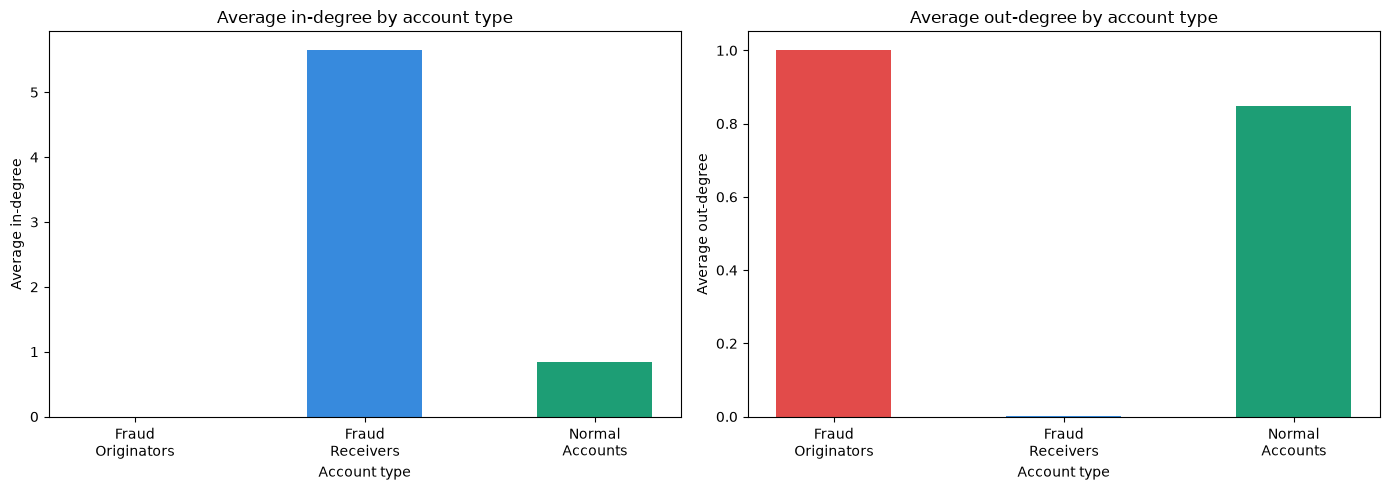

Figure saved to results/figures/


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# In-degree comparison
categories = ['Fraud\nOriginators', 'Fraud\nReceivers', 'Normal\nAccounts']
in_degrees = [
    np.mean(list(fraud_originators_in_degree.values())),
    np.mean(list(fraud_receivers_in_degree.values())),
    np.mean(list(normal_nodes_in_degree.values()))
]
out_degrees = [
    np.mean(list(fraud_originators_out_degree.values())),
    np.mean(list(fraud_receivers_out_degree.values())),
    np.mean(list(normal_nodes_out_degree.values()))
]

colors = ['#E24B4A', '#378ADD', '#1D9E75']

axes[0].bar(categories, in_degrees, color=colors, width=0.5)
axes[0].set_title('Average in-degree by account type')
axes[0].set_ylabel('Average in-degree')
axes[0].set_xlabel('Account type')

axes[1].bar(categories, out_degrees, color=colors, width=0.5)
axes[1].set_title('Average out-degree by account type')
axes[1].set_ylabel('Average out-degree')
axes[1].set_xlabel('Account type')

plt.tight_layout()
plt.savefig('../results/figures/degree_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to results/figures/")

## Finding 5: The two roles of fraud — visualised

![Degree comparison by account type](../results/figures/degree_comparison.png)

The two charts above make the structural argument visually. No numbers needed 
— the pattern is immediate.

### Left chart — in-degree (who receives money, and from how many)

Fraud receivers dominate at an average in-degree of 5.66, while fraud 
originators sit at exactly zero and normal accounts stay below 1. Receiving 
money from many different sources simultaneously is the defining structural 
characteristic of a fraud collection account. A normal account simply does 
not behave this way.

### Right chart — out-degree (who sends money, and how often)

Fraud originators hit exactly 1 — they send one transaction and exit the 
network entirely. Fraud receivers are essentially zero — they collect funds 
and stop, never distributing onwards. Normal accounts sit at 0.84, reflecting 
balanced participation: accounts that send also tend to receive, at similar 
rates.

### The complete picture

Two distinct fraud roles emerge from the network structure:

- **Originator accounts** — throwaway identities. Zero prior history in the 
  network, one outgoing fraudulent transaction, then gone. Structurally 
  invisible to a tabular model because their suspicious property is the 
  *absence* of incoming connections, not any feature of the transaction itself.

- **Collector accounts** — money mules. High in-degree, near-zero out-degree. 
  They sit at the end of the fraud chain pooling stolen funds from multiple 
  sources. A tabular model sees each incoming transaction independently and 
  misses the accumulation pattern entirely.

Neither role looks anything like normal account behaviour. Both are only 
detectable through graph structure — which is precisely why this project 
models the transaction network as a directed graph rather than treating each 
transaction as an independent data point.

In [18]:
fraud_amounts = [d['weighted'] for u,v,d in fraud_edges]
normal_amounts = [d['weighted'] for u,v,d in normal_edeges]

print("=== Transaction Amounts ===")
print(f"\nFraud transactions:")
print(f"  Mean: ${np.mean(fraud_amounts):.2f}")
print(f"  Median: ${np.median(fraud_amounts):.2f}")
print(f"  Max: ${np.max(fraud_amounts):.2f}")
print(f" Min: ${np.min(fraud_amounts):.2f}")

print(f"\nNormal transactions:")
print(f"  Mean: ${np.mean(normal_amounts):.2f}")
print(f"  Median: ${np.median(normal_amounts):.2f}")
print(f"  Max: ${np.max(normal_amounts):.2f}")
print(f"  Min: ${np.min(normal_amounts):.2f}")


=== Transaction Amounts ===

Fraud transactions:
  Mean: $1467967.30
  Median: $441423.44
  Max: $10000000.00
 Min: $0.00

Normal transactions:
  Mean: $314115.50
  Median: $171034.46
  Max: $92445516.64
  Min: $0.01


## Finding 6: Fraud transactions involve significantly larger amounts — but amount alone is not enough

| Statistic | Fraud transactions | Normal transactions |
|-----------|-------------------|---------------------|
| Mean      | $1,467,967        | $314,115            |
| Median    | $441,423          | $171,034            |
| Max       | $10,000,000       | $92,445,516         |
| Min       | $0.00             | $0.01               |

### The mean vs median gap — skewed distributions

For fraud transactions the mean ($1.47M) is more than 3 times the median 
($441K). This gap signals a heavily right-skewed distribution — most fraud 
transactions sit in the hundreds of thousands, but a small number of 
extremely large transactions near the $10M ceiling pull the average upward.

Normal transactions show the same pattern but less extreme — mean roughly 
double the median. In financial data, always report both. The mean alone 
gives a misleading picture of the typical transaction.

### The $10 million ceiling

The maximum fraud transaction is exactly $10,000,000 — a round number that 
almost certainly reflects a cap in the PaySim simulator rather than organic 
behaviour. It tells us the simulator models fraudsters as attempting to 
maximise stolen amounts. Large transaction size is therefore a fraud signal 
specific to this dataset.

### The $0 minimum — a data quality flag

A fraudulent transaction of $0.00 should not exist. A fraudster initiating 
a zero-dollar transfer makes no sense. This is likely a simulator artefact 
and will be filtered out during graph construction in notebook 02.

### Why amount alone is insufficient

Fraud transactions are on average 4.7 times larger than normal by mean, and 
2.6 times larger by median. Amount is a real fraud signal — and the XGBoost 
baseline in notebook 06 will use it directly.

But a large transaction is not automatically fraud. The normal dataset 
contains transactions up to $92 million — far above the fraud maximum of 
$10 million. What makes a transaction suspicious is not just its size but 
*who is sending it, who is receiving it, and what the network around those 
accounts looks like*.

Amount is a weak individual signal. Amount combined with graph structure — 
the in-degree of the receiver, the prior history of the sender, the 
transaction patterns of connected accounts — is a strong one. This is the 
cumulative argument the exploration notebook has been building: no single 
feature catches fraud reliably, but the graph sees the full picture.

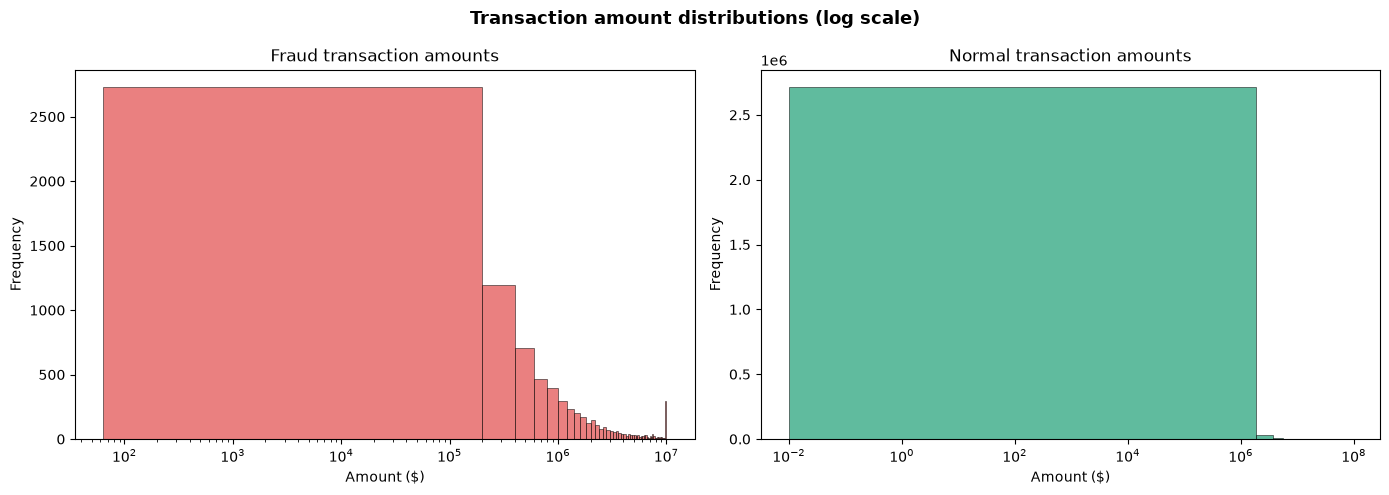

Figure saved.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# We use log scale because the amounts span many orders of magnitude
# Filter out zero amounts first
fraud_amounts_nonzero = [a for a in fraud_amounts if a > 0]
normal_amounts_nonzero = [a for a in normal_amounts if a > 0]

axes[0].hist(fraud_amounts_nonzero, bins=50, color='#E24B4A', 
             alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].set_title('Fraud transaction amounts')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xscale('log')

axes[1].hist(normal_amounts_nonzero, bins=50, color='#1D9E75',
             alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].set_title('Normal transaction amounts')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_xscale('log')

plt.suptitle('Transaction amount distributions (log scale)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/amount_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved.")

## Finding 7: Fraud amount distributions reveal two fraud behaviours

![Transaction amount distributions](../results/figures/amount_distributions.png)

### Left chart — fraud transactions (log scale)

Fraud amounts are spread across a wide range from ~$100 to the $10M ceiling. 
The distribution shows a possible bimodal shape — a large concentration of 
smaller frauds between $100 and $100,000, and a second cluster between 
$500,000 and $2,000,000. This may reflect two distinct fraud patterns in 
the PaySim simulator: small opportunistic frauds and large targeted ones. 
This warrants further investigation in notebook 03.

### Right chart — normal transactions (log scale)

Normal transactions are overwhelmingly concentrated in a single range — 
$10,000 to $10,000,000 — with almost no spread outside it. The distribution 
is tight and predictable.

### The key contrast

Fraud amounts are far more variable than normal amounts. High variability 
in transaction size is itself a fraud signal — honest financial behaviour 
tends to be patterned and consistent, while fraudulent behaviour is erratic 
and amount-maximising.

### Implication for modelling

Transaction amount will be included as a feature in both the XGBoost 
baseline (notebook 06) and the graph model. However as established in 
Finding 6, amount alone is insufficient — the normal dataset contains 
transactions far larger than any fraud transaction. Amount gains predictive 
power when combined with graph structural features, not on its own.